Average Marks: 84.66666666666667

City-wise Average:
 city
Delhi      85.0
Patna      84.0
Unknown    85.0
Name: marks, dtype: float64

Top Student:
 name          E
marks      95.0
city      Delhi
grade      High
status     Pass
Name: 4, dtype: object

City with Most Students: Delhi

Pass Percentage: 83.33333333333334


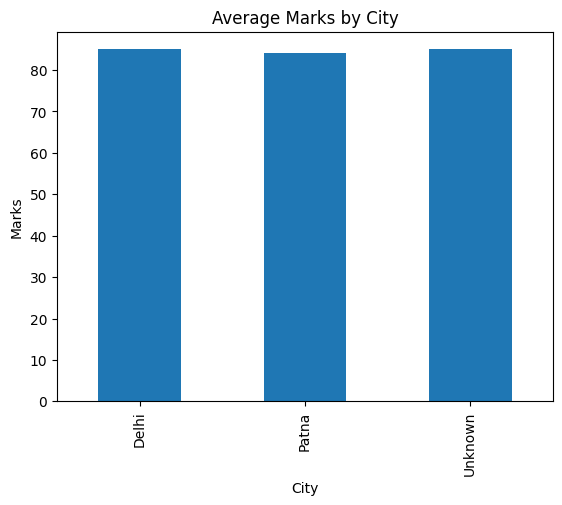

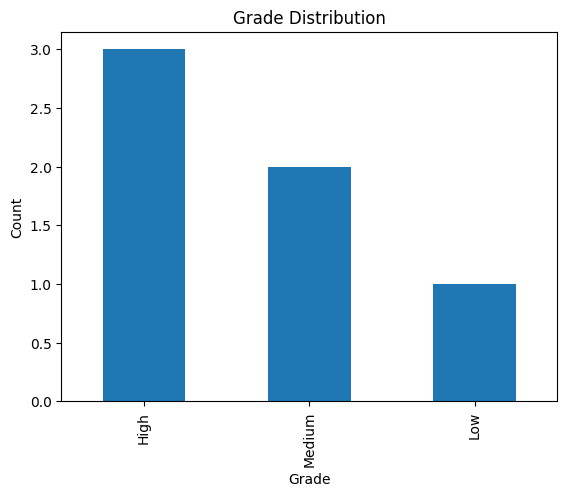

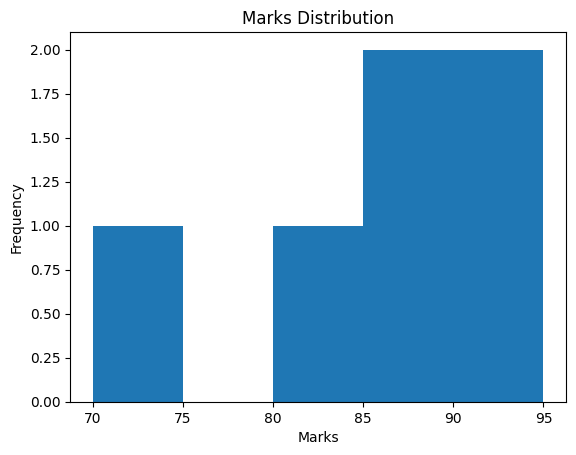

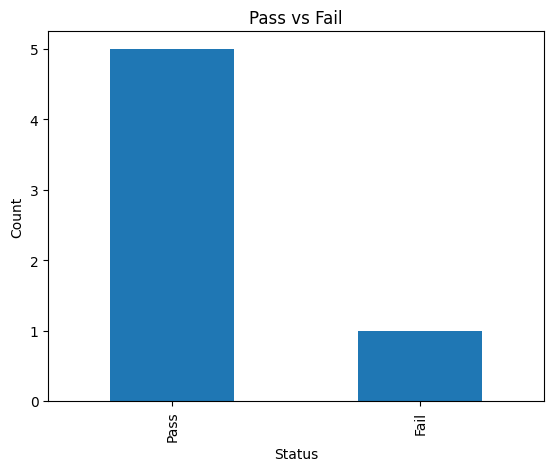

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 1️⃣ Create Dataset
# -------------------------------
data = {
    'name': ['A','B','C','D','E','F','G','H'],
    'marks': ['80','90','NaN','85','95','error','88','70'],
    'city': ['Patna','Delhi','Mumbai',None,'Delhi','Mumbai','Patna','Delhi']
}

df = pd.DataFrame(data)

# -------------------------------
# 2️⃣ Data Cleaning
# -------------------------------

# convert marks to numeric
df['marks'] = pd.to_numeric(df['marks'], errors='coerce')

# fill missing city
df['city'] = df['city'].fillna('Unknown')

# drop rows with missing marks
df = df.dropna(subset=['marks'])

# -------------------------------
# 3️⃣ Feature Engineering
# -------------------------------

# grade column
df['grade'] = pd.cut(df['marks'],
                     bins=[0,70,85,100],
                     labels=['Low','Medium','High'])

# pass/fail column
df['status'] = df['marks'].apply(lambda x: 'Pass' if x >= 75 else 'Fail')

# -------------------------------
# 4️⃣ Analysis
# -------------------------------

# average marks
avg_marks = df['marks'].mean()

# city wise average marks
city_avg = df.groupby('city')['marks'].mean()

# top scorer
top_student = df.loc[df['marks'].idxmax()]

# city with most students
top_city = df['city'].value_counts().idxmax()

# pass percentage
pass_percent = (df['status'] == 'Pass').mean() * 100

# print results
print("Average Marks:", avg_marks)
print("\nCity-wise Average:\n", city_avg)
print("\nTop Student:\n", top_student)
print("\nCity with Most Students:", top_city)
print("\nPass Percentage:", pass_percent)

# -------------------------------
# 5️⃣ Visualization
# -------------------------------

# Avg marks by city
city_avg.plot(kind='bar')
plt.title("Average Marks by City")
plt.xlabel("City")
plt.ylabel("Marks")
plt.show()

# Grade distribution
df['grade'].value_counts().plot(kind='bar')
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

# Marks histogram
df['marks'].plot(kind='hist', bins=5)
plt.title("Marks Distribution")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

# Pass vs Fail
df['status'].value_counts().plot(kind='bar')
plt.title("Pass vs Fail")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()